In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

# 1. Folder in Drive that you showed in the screenshot
SRC_DIR = "/content/drive/MyDrive/Sora Face Dataset"

# 2. Where to create the zip (without .zip at the end for make_archive)
ZIP_BASE = "/content/drive/MyDrive/Sora_Face_Dataset"

assert os.path.isdir(SRC_DIR), f"Source folder not found: {SRC_DIR}"

# 3. Make zip: this creates /content/drive/MyDrive/Sora_Face_Dataset.zip
shutil.make_archive(ZIP_BASE, 'zip', SRC_DIR)

print("Created ZIP at:", ZIP_BASE + ".zip")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Created ZIP at: /content/drive/MyDrive/Sora_Face_Dataset.zip


In [7]:
import zipfile, os, shutil

ZIP_PATH = "/content/drive/MyDrive/Sora_Face_Dataset.zip"
EXTRACT_DIR = "/content/sora_faces_raw"

# Clean old extraction if re-running
if os.path.isdir(EXTRACT_DIR):
    print("Cleaning previous extracted folder...")
    shutil.rmtree(EXTRACT_DIR)

print(f"Unzipping {ZIP_PATH} to {EXTRACT_DIR} ...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("Done extracting.")

print("Subfolders inside:", os.listdir(EXTRACT_DIR))


Cleaning previous extracted folder...
Unzipping /content/drive/MyDrive/Sora_Face_Dataset.zip to /content/sora_faces_raw ...
Done extracting.
Subfolders inside: ['Black Demographic Group', 'White Demographic Group', 'Asian Demographic Group']


In [8]:
import os
from PIL import Image
from tqdm import tqdm

INPUT_ROOT  = "/content/sora_faces_raw/Sora Face Dataset"  # sometimes zip adds one more folder layer
if not os.path.isdir(INPUT_ROOT):
    # fallback: maybe the three folders are directly under EXTRACT_DIR
    INPUT_ROOT = "/content/sora_faces_raw"

OUTPUT_ROOT = "/content/sora_faces_224"   # new preprocessed dataset

TARGET_SIZE = 224  # 224x224

os.makedirs(OUTPUT_ROOT, exist_ok=True)

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def process_image(in_path, out_path, size=TARGET_SIZE):
    img = Image.open(in_path)

    # ... (grayscale and RGB conversion code remains the same)
    img = img.convert("L")
    img = img.convert("RGB")

    # ... (resize logic remains the same)
    w, h = img.size
    if min(w, h) != size:
        # resize preserving aspect ratio
        if w < h:
            new_w = size
            new_h = int(h * size / w)
        else:
            new_h = size
            new_w = int(w * size / h)
        img = img.resize((new_w, new_h), Image.BICUBIC)
        w, h = img.size

    # 1. Define the upward shift (offset)
    # This value determines how much the crop moves UP from the center.
    # A larger number means shifting the crop higher.
    # Example: Shift up by 20% of the cropped area height (size * 0.2)
    crop_offset = int(size * 0.2)  # Adjust 0.2 (20%) as needed

    # 2. Calculate New Crop Coordinates
    left   = (w - size) // 2

    # Calculate the original center top position
    center_top = (h - size) // 2

    # Shift the top coordinate UP by subtracting the offset
    top    = center_top - crop_offset

    # Ensure the top coordinate doesn't go negative
    top    = max(0, top)

    right  = left + size
    bottom = top + size

    # 3. Perform the Crop
    img = img.crop((left, top, right, bottom))

    # ... (rest of the saving code remains the same)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    img.save(out_path)

# Walk over all files and process
all_files = []
for root, dirs, files in os.walk(INPUT_ROOT):
    for f in files:
        if os.path.splitext(f)[1].lower() in valid_exts:
            in_path  = os.path.join(root, f)
            rel_path = os.path.relpath(in_path, INPUT_ROOT)
            out_path = os.path.join(OUTPUT_ROOT, rel_path)
            all_files.append((in_path, out_path))

print(f"Found {len(all_files)} images.")

for in_path, out_path in tqdm(all_files):
    try:
        process_image(in_path, out_path)
    except Exception as e:
        print("Error processing:", in_path, "->", e)

print("Done preprocessing.")
print("Top-level folders in OUTPUT_ROOT:", os.listdir(OUTPUT_ROOT))

Found 114 images.


100%|██████████| 114/114 [00:05<00:00, 19.28it/s]

Done preprocessing.
Top-level folders in OUTPUT_ROOT: ['Black Demographic Group', 'White Demographic Group', 'Asian Demographic Group']


Total processed images found: 114
Sample image: /content/sora_faces_224/White Demographic Group/WhitePerson18.png


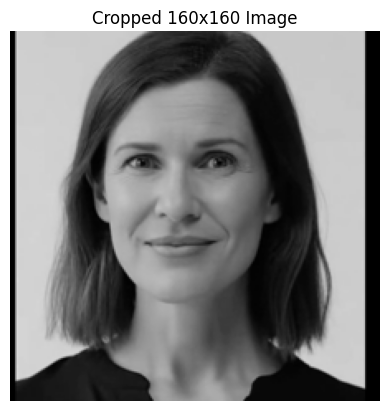

In [18]:
import random
from PIL import Image
import matplotlib.pyplot as plt

OUTPUT_ROOT = "/content/sora_faces_224"

# Get all processed image paths
all_imgs = []
for root, dirs, files in os.walk(OUTPUT_ROOT):
    for f in files:
        if f.lower().endswith(("jpg", "jpeg", "png")):
            all_imgs.append(os.path.join(root, f))

print("Total processed images found:", len(all_imgs))

# Pick one at random
sample_path = random.choice(all_imgs)
print("Sample image:", sample_path)

# Show it
img = Image.open(sample_path)
plt.imshow(img)
plt.axis("off")
plt.title("Cropped 160x160 Image")
plt.show()


In [19]:
import shutil
import os

# Define the source (processed folder) and the destination (Google Drive)
SOURCE_FOLDER = "/content/sora_faces_224"
FINAL_ZIP_BASE = "/content/drive/MyDrive/Sora_Processed_Faces"

print("Compressing processed images...")

# Create the archive and save it to Google Drive
shutil.make_archive(
    FINAL_ZIP_BASE,
    'zip',
    SOURCE_FOLDER
)

print(f"✅ Successfully created final ZIP file and saved to Drive: {FINAL_ZIP_BASE}.zip")

Compressing processed images...
✅ Successfully created final ZIP file and saved to Drive: /content/drive/MyDrive/Sora_Processed_Faces.zip
